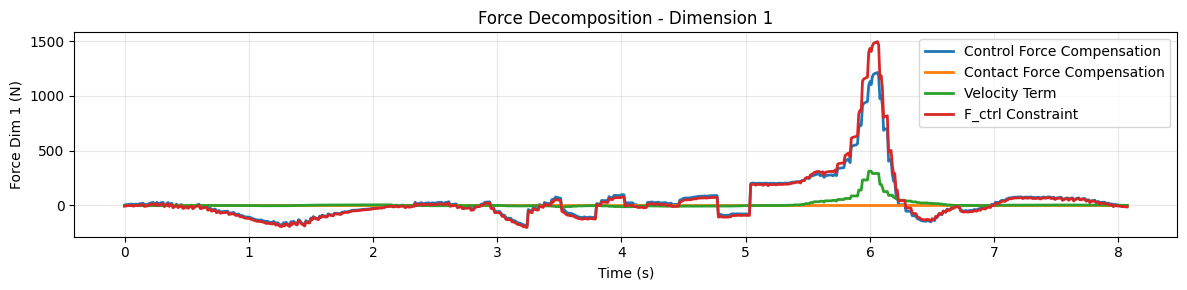

[INFO] Loaded data with 808 timesteps and 1 dimension(s)
[PLOT] Figure saved to plots/force_decomposition_from_npz.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_force_details(npz_path: str , dt: float = 0.01, transition_time: float = 0.0):
    """
    Read and plot force decomposition data from npz file.
    
    Args:
        npz_path: Path to the .npz file
        dt: Time step for generating time axis
        transition_time: Time offset for the x-axis (optional)
    """
    # Load data
    data = np.load(npz_path)
    
    control_comp = data['control_force_compensation_arr']
    contact_comp = data['contact_force_compensation_arr']
    velocity_term = data['velocity_term_arr']
    f_ctrl_constraint = data['F_ctrl_constraint_arr']
    
    # Convert to arrays if they're lists
    control_comp = np.array(control_comp)
    contact_comp = np.array(contact_comp)
    velocity_term = np.array(velocity_term)
    f_ctrl_constraint = np.array(f_ctrl_constraint)
    
    # Determine dimensions
    timesteps = len(control_comp)
    t = np.arange(timesteps) * dt + transition_time
    
    # Handle dimensionality
    if control_comp.ndim == 1:
        n_dim = 1
        control_comp = control_comp[:, None]
        contact_comp = contact_comp[:, None]
        velocity_term = velocity_term[:, None]
        f_ctrl_constraint = f_ctrl_constraint[:, None]
    else:
        n_dim = control_comp.shape[1]
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_dim, 1, figsize=(12, 3 * n_dim))
    if n_dim == 1:
        axes = [axes]
    
    # Plot each dimension
    for i in range(n_dim):
        axes[i].plot(t, control_comp[:, i], label='Control Force Compensation', linewidth=2)
        axes[i].plot(t, contact_comp[:, i], label='Contact Force Compensation', linewidth=2)
        axes[i].plot(t, velocity_term[:, i], label='Velocity Term', linewidth=2)
        axes[i].plot(t, f_ctrl_constraint[:, i], label='F_ctrl Constraint', linewidth=2)
        axes[i].set_ylabel(f'Force Dim {i + 1} (N)')
        axes[i].legend(loc='best')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_title(f'Force Decomposition - Dimension {i + 1}')
    
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.savefig("force_decomposition_from_npz.png", dpi=150)
    plt.show()
    
    print(f"[INFO] Loaded data with {timesteps} timesteps and {n_dim} dimension(s)")
    print("[PLOT] Figure saved to plots/force_decomposition_from_npz.png")


if __name__ == "__main__":
    # Example usage
    plot_force_details(r"C:\Users\11452\wkspace\mj_ctrl\force_details.npz", dt=0.01, transition_time=0.0)